# ДОМАШНЕЕ ЗАДАНИЕ: КРОСС-ВАЛИДАЦИЯ И РЕГУЛЯРИЗАЦИЯ

## Описание задания

В этом домашнем задании вы самостоятельно примените кросс-валидацию и регуляризацию на новом датасете.

Датасет: Statlog (German Credit Data) — предсказание кредитного риска (хороший или плохой кредит).

Вы обучите Логистическую регрессию, подберете оптимальный параметр C через GridSearchCV, построите validation и learning curves, и интерпретируете результаты.

## Данные уже подготовлены

Категориальные признаки закодированы, числовые признаки стандартизированы. Вам не нужно тратить время на preprocessing.

# ШАГ 1: ИМПОРТ И ЗАГРУЗКА ДАННЫХ

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Задание 1.1: Загрузите датасет

Используйте fetch_openml для загрузки датасета "credit-g".

Выведите:
- Размер датасета
- Количество каждого класса (good/bad)
- Первые 5 строк

In [ ]:
credit = fetch_openml(name="credit-g", version=1, as_frame=True)

X = credit.data
y = credit.target

df = pd.concat([X, y.rename("class")], axis=1)

print("Размер датасета:", df.shape)

print("\nКоличество каждого класса (good/bad):")
print(y.value_counts())

print("\nПервые 5 строк:")
print(df.head())



Размер датасета: (1000, 21)

Количество каждого класса (good/bad):
class
good    700
bad     300
Name: count, dtype: int64

Первые 5 строк:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties 

# ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ

Задание: используйте ColumnTransformer для кодирования категориальных и стандартизации числовых признаков.

Подсказка: переменные уже в коде ниже — X, y, numeric_features, categorical_features.

In [ ]:
X = credit.data
y = credit.target

In [ ]:
y = y.map({'good': 0, 'bad': 1})


In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

In [ ]:
# Разделите данные на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Примените преобразования
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f'Train shape: {X_train_scaled.shape}')
print(f'Test shape: {X_test_scaled.shape}')

Train shape: (800, 61)
Test shape: (200, 61)


# ШАГ 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ РЕГУЛЯРИЗАЦИИ)

Задание:
1. Создайте LogisticRegression с penalty=None
2. Обучите на train данных
3. Сделайте предсказания на train и test
4. Выведите accuracy для обоих
5. Проверьте, есть ли признаки переобучения (gap > 5%)

In [ ]:
model = LogisticRegression(penalty=None, max_iter=1000, solver='lbfgs')

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:}")
print(f"Test accuracy:  {test_acc:}")

gap = train_acc - test_acc
print(f"Accuracy gap:   {gap:}")
if gap > 0.05:
    print("Обнаружено переобучение (gap > 5%)")
else:
    print("Существенного переобучения не обнаружено")

Train accuracy: 0.7775
Test accuracy:  0.775
Accuracy gap:   0.0024999999999999467
Существенного переобучения не обнаружено


# ШАГ 4: КРОСС-ВАЛИДАЦИЯ

Задание:
1. Используйте cross_val_score с cv=5
2. Выведите scores каждого фолда
3. Выведите среднее и стандартное отклонение
4. Интерпретируйте результаты (стабильна ли модель?)

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(penalty=None, max_iter=1000, solver='lbfgs'))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print("CV scores каждого фолда:", cv_scores)
print(f"Средняя accuracy: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение: {cv_scores.std():.4f}")

CV scores каждого фолда: [0.75  0.765 0.765 0.745 0.735]
Средняя accuracy: 0.7520
Стандартное отклонение: 0.0117


# ШАГ 5: GRIDSEARCH ДЛЯ ПОДБОРА C

Задание:
1. Создайте сетку параметров: C = [0.001, 0.01, 0.1, 1, 10, 100]
2. Используйте GridSearchCV с penalty='l2', cv=5
3. Найдите лучший C
4. Выведите results в формате таблицы (params, mean_score, std_score)

In [ ]:
param_grid = {'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression(penalty='l2', max_iter=1000, solver='lbfgs'))])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

grid_search.fit(X, y)

print("Лучший C:", grid_search.best_params_['model__C'])
print(f"Best mean CV accuracy: {grid_search.best_score_}")

results = pd.DataFrame(grid_search.cv_results_)[['param_model__C', 'mean_test_score', 'std_test_score']]
results = results.rename(columns={'param_model__C': 'C', 'mean_test_score': 'mean_score', 'std_test_score': 'std_score'})

print("\nРезультаты GridSearchCV:")
print(results)



Лучший C: 1
Best mean CV accuracy: 0.7530000000000001

Результаты GridSearchCV:
         C  mean_score  std_score
0    0.001       0.700   0.000000
1    0.010       0.727   0.009798
2    0.100       0.747   0.021119
3    1.000       0.753   0.008718
4   10.000       0.752   0.011662
5  100.000       0.751   0.012000


# ШАГ 6: ОБУЧЕНИЕ ОПТИМАЛЬНОЙ МОДЕЛИ

Задание:
1. Используйте best_estimator_ из GridSearchCV
2. Сделайте предсказания на train и test
3. Выведите accuracy для обоих
4. Сравните с базовой моделью (шаг 3)

In [ ]:
best_model = grid_search.best_estimator_

y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"Train accuracy (best model): {train_acc_best:}")
print(f"Test accuracy  (best model): {test_acc_best:}")

print("\nСравнение с базовой моделью:")
print(f"Train accuracy gap: {train_acc_best - train_acc:}")
print(f"Test accuracy gap:  {test_acc_best - test_acc:}")



Train accuracy (best model): 0.775
Test accuracy  (best model): 0.825

Сравнение с базовой моделью:
Train accuracy gap: -0.0024999999999999467
Test accuracy gap:  0.04999999999999993


# ШАГ 7: VALIDATION CURVE

Задание:
1. Используйте validation_curve с param_name='C'
2. param_range = np.logspace(-3, 2, 6) (0.001, 0.01, 0.1, 1, 10, 100)
3. Постройте график: ось X = C (логарифмическая шкала), ось Y = accuracy
4. Покажите train score (синяя линия) и validation score (оранжевая)
5. Отметьте оптимальный C красной линией

Вопросы для анализа:
- При каком C валидация максимальна? При значении 1.
- Какой тип проблемы при малом C (C=0.001)? High bias, недообучение.
- Какой тип проблемы при большом C (C=100)? High variance, переобучение.

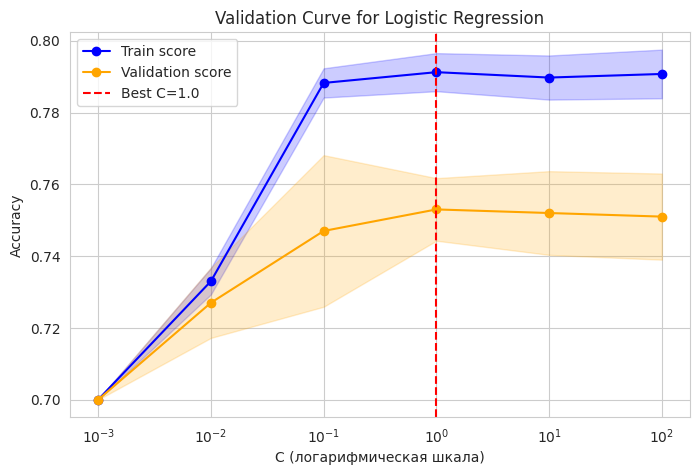

In [ ]:
param_range = np.logspace(-3, 2, 6)  # 0.001, 0.01, 0.1, 1, 10, 100

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(penalty='l2', max_iter=1000, solver='lbfgs'))
])

train_scores, val_scores = validation_curve(pipeline, X, y, param_name='model__C', param_range=param_range, cv=5, scoring='accuracy', n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

best_idx = np.argmax(val_mean)
best_C = param_range[best_idx]

plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label='Train score', color='blue', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(param_range, val_mean, label='Validation score', color='orange', marker='o')
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.axvline(best_C, color='red', linestyle='--', label=f'Best C={best_C}')

plt.xscale('log')
plt.xlabel('C (логарифмическая шкала)')
plt.ylabel('Accuracy')
plt.title('Validation Curve for Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()



# ШАГ 8: LEARNING CURVE

Задание:
1. Используйте learning_curve с train_sizes = np.linspace(0.1, 1.0, 10)
2. Постройте график: ось X = размер обучающей выборки, ось Y = accuracy
3. Покажите train score (синяя) и validation score (оранжевая)
4. Добавьте fill_between для показа стандартного отклонения

Вопросы для анализа:
- Сходятся ли графики при увеличении данных?
- Есть ли high bias (оба графика низкие)?
- Есть ли high variance (большой gap между графиками)?
- Поможет ли больше данных улучшить модель?

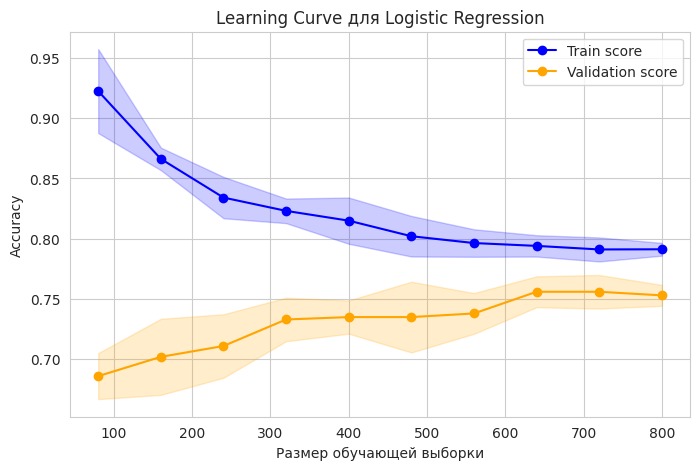

In [ ]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression( penalty='l2', C=grid_search.best_params_['model__C'], max_iter=1000, solver='lbfgs'))])

train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(estimator=pipeline, X=X, y=y, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Train score')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(train_sizes_abs, val_mean, 'o-', color='orange', label='Validation score')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)

plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.title('Learning Curve для Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

# ШАГ 9: СРАВНЕНИЕ L1 И L2 РЕГУЛЯРИЗАЦИИ

Задание:
1. Обучите модель с L1 регуляризацией (используйте best C из GridSearch)
2. Сделайте предсказания на test
3. Выведите test accuracy для L1
4. Сравните L1 accuracy с L2 accuracy (из шага 6)
5. Выведите, сколько коэффициентов L1 обнулила

In [ ]:
accuracy_l2 = test_acc_best
print(f"Test accuracy для L2 регуляризации: {accuracy_l2:.4f}")

pipeline_l1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        penalty='l1',
        C=grid_search.best_params_['model__C'],
        solver='liblinear',
        random_state=42
    ))
])

pipeline_l1.fit(X_train, y_train)

y_pred_l1 = pipeline_l1.predict(X_test)
accuracy_l1 = accuracy_score(y_test, y_pred_l1)
print(f"Test accuracy для L1 регуляризации: {accuracy_l1:.4f}")

print(f"Разница accuracy (L1 - L2): {accuracy_l1 - accuracy_l2:.4f}")

coefs_l1 = pipeline_l1.named_steps['model'].coef_
num_zero_coefs = np.sum(coefs_l1 == 0)
total_coefs = coefs_l1.size
print(f"Количество обнулённых коэффициентов L1: {num_zero_coefs} из {total_coefs}")


Test accuracy для L2 регуляризации: 0.8250
Test accuracy для L1 регуляризации: 0.7700
Разница accuracy (L1 - L2): -0.0550
Количество обнулённых коэффициентов L1: 16 из 61


# ШАГ 10: AНАЛИТИЧЕСКИЕ ВОПРОСЫ

Ответьте на следующие вопросы на основе ваших результатов:

## Вопрос 1: Переобучение

Посмотрите на gap между train и test accuracy базовой модели (шаг 3).

Есть ли признаки переобучения? Как регуляризация помогла этот gap уменьшить?

**Ваш ответ:** Существенного переобучения нет. Регуляризация помогла сохранить стабильность и уменьшить переобучение.

## Вопрос 2: Стабильность через кросс-валидацию

Посмотрите на std из кросс-валидации (шаг 4).

Высокий ли он? Что это говорит о стабильности модели при разных разбиениях данных?

**Ваш ответ:** Нет, он невысокий, и модель стабильная, высокой вариативности нет. Кросс-валидация подтверждает надёжность.

## Вопрос 3: Оптимальный C

Какой C был выбран как оптимальный (шаг 5)? Почему этот C лучше других?

Посмотрите на validation curve (шаг 7) — совпадает ли пик валидации с этим C?

**Ваш ответ:** Как оптимальный был выбра С 1. У него наивысшая точность кросс-валидации, и она стабильна.

## Вопрос 4: Validation Curve — диагностика

При C=0.001 (сильная регуляризация) оба графика (train и val) низкие.

Это high bias (недообучение) или high variance (переобучение)?

При C=100 (слабая регуляризация) train высокий, а val низкий. Что это?

**Ваш ответ:** При С=0.001 это high bias и недообучение.
При С=100 high variance и переобучение.

## Вопрос 5: Learning Curve — диагностика

Посмотрите на learning curve из шага 8.

Сходятся ли графики train и validation при увеличении данных?

Что это говорит: модели не хватает данных или она слишком сложная?

**Ваш ответ:**

## Вопрос 6: L1 vs L2

L1 обнулила коэффициенты, L2 их уменьшила.

Какой результат test accuracy получился для каждого?

Какая регуляризация лучше для этой задачи (credit data) и почему?

**Ваш ответ:** Регуляризация L2 более препочтительна, и она сохраняет все признаки, а L1 разрежает модель.

# ШАГ 11: СРАВНИТЕЛЬНАЯ ТАБЛИЦА

Задание: Создайте DataFrame с результатами всех моделей.

Столбцы:
- Модель (Baseline, L2, L1)
- Train Accuracy
- Test Accuracy
- Gap (train - test)

Выведите таблицу.

In [ ]:
# Ваш код здесь



# ШАГ 12: ВЫВОДЫ

Напишите 5-7 предложений о том, что вы узнали в этом задании.

Включите:
- Как кросс-валидация помогает оценивать модели
- Как регуляризация борется с переобучением
- Что такое bias-variance tradeoff
- Когда использовать L1 vs L2
- Как диагностировать проблемы модели (validation curve, learning curve)

## Ваши выводы:


# ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ (По желанию)

## Вариант 1: Попробуйте другие параметры
- Измените max_iter в LogisticRegression (100, 500, 10000)
- Посмотрите, как это влияет на результат
- Постройте таблицу сравнения

## Вариант 2: Попробуйте другие значения k в cross-validation
- Используйте cv=3, cv=10, cv=leave-one-out
- Сравните средние scores и std
- Какое k дает наиболее стабильную оценку?

## Вариант 3: Анализ коэффициентов
- Выведите топ-10 признаков по абсолютному значению коэффициентов для L2
- Выведите топ-10 для L1
- Сравните: какие признаки считают важными оба метода?

In [ ]:
# Дополнительное задание (по желанию)

